In [13]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pymutspec.annotation import filter_outlier_branches, mutations_summary, get_cossim

In [14]:
import os
os.listdir('data')

['trees',
 'nucl_4f_freq_all_virus.csv',
 'mean_gr_eq_freq.csv',
 'virus_taxid_host_gene.csv',
 'nucl_all_freq_all_virus.csv',
 'nucl_eq_freq_sars_cov2.csv',
 'nucl_eq_freq_all_virus.csv',
 'allmut_nemu.csv',
 'ms12syn_all_virus.csv',
 '.gitignore',
 'eq_freq_viral_groups_boxplot.csv',
 'Bloom_etal',
 'allmut_nemu.zip',
 'viral_taxid_info_be.csv',
 'nemu_inputs',
 'species.csv',
 'virs_rnd_fit_metrics.csv',
 'mutation_summary_vir.csv',
 'vir_linages.csv',
 'aa_equilibrium_freq.csv',
 'aminoacid_freq_all_virus.csv',
 'cossim_nemu_bloom.csv',
 'distance_to_eq.csv',
 'refseq',
 'taxid_virus_type.csv',
 'viral_spectra_dataset.csv',
 'viral_spectra_long.csv',
 'viral_meta_table.csv',
 'legacy_suppl_table3.csv']

In [15]:
mutations = pd.read_csv('data/allmut_nemu.csv')
mutations['sbs12'] = mutations['Mut'].str.slice(2, -2)
spectra = pd.read_csv('data/viral_spectra_dataset.csv')#.query('df == "nemu"')
raw_spectra = pd.read_csv('data/ms12syn_all_virus.csv')
host_gene = pd.read_csv('data/virus_taxid_host_gene.csv')
vir_type = pd.read_csv('data/taxid_virus_type.csv', index_col=0)
linages = pd.read_csv('data/vir_linages.csv')
seq_cnt = pd.read_csv('data/nemu_inputs/seq_cnt.csv') # 3052310(11620),156,7587

# vir_type['taxid'] = vir_type['taxid'].astype(int)

In [16]:
raw_spectra.taxid.nunique()

32

In [17]:
names = spectra[['Type', 'taxid', 'taxname', 'virusname', 'df']]\
    .rename(columns={'df': 'dataset', 'Type': 'type', 'virusname': 'label'})\
        .sort_values(['type', 'taxid'])
names['type'] = names['type'].map({'+': '+ssRNA', '-': '-ssRNA', 'ds': 'dsRNA',})
names.index = range(1, len(names) + 1)
names.index.name = 'id'
names

,type,taxid,taxname,label,dataset
id,,,,,
1,+ssRNA,11082,West Nile virus,WNV,nemu
2,+ssRNA,11983,Norwalk virus,norw,nemu
3,+ssRNA,12092,Hepatovirus A,HAV,nemu
4,+ssRNA,12110,Foot-and-mouth disease virus,FMDV,nemu
5,+ssRNA,12162,Citrus tristeza virus,CTV,nemu
6,+ssRNA,12637,Dengue virus,denv,nemu
7,+ssRNA,28295,Porcine epidemic diarrhea virus,PEDV,nemu
8,+ssRNA,28344,Porcine reproductive and respiratory syndrome ...,PRRSV,nemu
9,+ssRNA,54290,GB virus C,HGV,nemu


## Long spectra table

In [18]:
spectra_long = raw_spectra.merge(names, on='taxid', how='left')\
    .drop(columns=['MutSpec_q05', 'MutSpec_median', 'MutSpec_q95'])\
        .rename(columns={'ObsNum': 'ObsCnt'})
spectra_long['ExpFreq'] = spectra_long['ExpNum'] / spectra_long['ExpNum'].sum()
# spectra_long['MutSpec2'] = spectra_long['ObsCnt'] / spectra_long['ExpFreq']  
# spectra_long['MutSpec2'] = spectra_long['MutSpec2'] / spectra_long['MutSpec2'].sum()
spectra_long = spectra_long[['Mut', 'ObsCnt', 'ExpFreq', 'MutSpec', 'taxid', 'type', 'taxname', 'label', 'dataset']]
spectra_long['type'] = spectra_long['type'].map({'+ssRNA': '(+)ssRNA', '-ssRNA': '(-)ssRNA', 'dsRNA': 'dsRNA'})
spectra_long 

,Mut,ObsCnt,ExpFreq,MutSpec,taxid,type,taxname,label,dataset
0,A>C,222.10000,0.000871,0.109127,10407,dsRNA,Hepatitis B virus,HBV,nemu
1,A>G,348.58100,0.001271,0.117342,10407,dsRNA,Hepatitis B virus,HBV,nemu
2,A>T,114.44900,0.000667,0.073464,10407,dsRNA,Hepatitis B virus,HBV,nemu
3,C>A,172.60900,0.001226,0.060217,10407,dsRNA,Hepatitis B virus,HBV,nemu
4,C>G,28.65490,0.001049,0.011690,10407,dsRNA,Hepatitis B virus,HBV,nemu
...,...,...,...,...,...,...,...,...,...
379,G>C,2.13421,0.000579,0.003805,77763,dsRNA,Banna virus,BAV,nemu
380,G>T,50.06880,0.000579,0.089263,77763,dsRNA,Banna virus,BAV,nemu
381,T>A,49.02400,0.001582,0.032003,77763,dsRNA,Banna virus,BAV,nemu
382,T>C,478.02300,0.003835,0.128729,77763,dsRNA,Banna virus,BAV,nemu


In [19]:
# recheck data from spectra_long and spectra
a = spectra_long.pivot(index=['label'], columns='Mut', values='MutSpec').fillna(0)
b = spectra.set_index('virusname')[a.columns]

get_cossim(a, b)

ACoV      1.0
BAV       1.0
CTV       1.0
DWV       1.0
EBLV1     1.0
EHDV      1.0
FMDV      1.0
HAV       1.0
HBV       1.0
HCV       1.0
HEV       1.0
HGV       1.0
HMV       1.0
MRV       1.0
OROV      1.0
PEDV      1.0
PRRSV     1.0
PRV       1.0
PUUV      1.0
RBSDV     1.0
RSV       1.0
SBV       1.0
WNV       1.0
aka       1.0
alCoV1    1.0
aorv      1.0
denv      1.0
evA       1.0
evC       1.0
evD       1.0
flu_a     1.0
norw      1.0
dtype: float64

In [20]:
spectra.query('df == "Bloom_etal"')

,A>C,A>G,A>T,C>A,C>G,C>T,G>A,G>C,G>T,T>A,T>C,T>G,Type,taxname,df,taxid,virusname
32,0.007703,0.070279,0.038923,0.053017,0.002418,0.290197,0.334728,0.000332,0.040141,0.033842,0.120245,0.008174,-,RSV-A,Bloom_etal,208893,rsv-a
33,0.007791,0.044050,0.014029,0.019518,0.007484,0.409514,0.101614,0.016632,0.324148,0.008769,0.040320,0.006130,+,SARS-CoV-2 20A,Bloom_etal,2697049,CoV20A
34,0.005280,0.061198,0.014484,0.029170,0.003536,0.474034,0.127443,0.013234,0.198024,0.011246,0.055648,0.006704,+,SARS-CoV-2 22C,Bloom_etal,2697049,CoV22C


In [21]:
# add from Bloom_etal
import json

with open('data/Bloom_etal/other_virus_spectra_Bloom_etal.json', 'r') as f:
    otherv = json.load(f)
rsva = pd.DataFrame(otherv['rsv-a'])
rsva_nuc_freqs = rsva.iloc[-4:, 2:]
rsva_spec = rsva.iloc[:-4, :2]
rsva_spec = rsva_spec.reset_index().rename(columns={'index': 'Mut', 'mutation_counts': 'ObsCnt', 'mutation_spectrum': 'MutSpec'})
rsva_spec['MutSpec'] = rsva_spec['MutSpec'] / rsva_spec['MutSpec'].sum()
rsva_spec['Mut'] = rsva_spec['Mut'].str.replace('to', '>')
rsva_spec['Nuc'] = rsva_spec['Mut'].str[0]
rsva_spec['ExpFreq'] = rsva_spec['Nuc'].map(rsva_nuc_freqs.empirical_frequencies.to_dict())
rsva_spec['ExpFreq'] = rsva_spec['ExpFreq'] / rsva_spec['ExpFreq'].sum()
rsva_spec['taxid'] = 208893
rsva_spec['taxname'] = 'RSV-A'
rsva_spec['type'] = '(-)ssRNA'
rsva_spec['label'] = 'rsv-a'
rsva_spec['dataset'] = 'Bloom_etal'
rsva_spec

,Mut,ObsCnt,MutSpec,Nuc,ExpFreq,taxid,taxname,type,label,dataset
0,A>G,1031.0,0.070279,A,0.138553,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
1,G>A,1009.0,0.334728,G,0.028470,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
2,T>C,1471.0,0.120245,T,0.115540,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
3,C>T,1560.0,0.290197,C,0.050771,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
4,A>T,571.0,0.038923,A,0.138553,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
5,T>G,100.0,0.008174,T,0.115540,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
6,G>T,121.0,0.040141,G,0.028470,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
7,T>A,414.0,0.033842,T,0.115540,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
8,C>A,285.0,0.053017,C,0.050771,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal
9,A>C,113.0,0.007703,A,0.138553,208893,RSV-A,(-)ssRNA,rsv-a,Bloom_etal


In [22]:
# add sars-cov-2 spectra

sars_cov_2_spec = pd.read_csv('data/Bloom_etal/rates_by_clade.csv').query('clade in ["20A", "22C"]')
sars_cov_2_spec['Mut'] = sars_cov_2_spec['mut_type'].str.replace('to', '>')
sars_cov_2_spec['ObsCnt'] = sars_cov_2_spec['count']

sars_cov_2_spec20a = sars_cov_2_spec.query('clade == "20A"')
sars_cov_2_spec22c = sars_cov_2_spec.query('clade == "22C"')

sars_cov_2_spec20a['ExpFreq'] = sars_cov_2_spec20a['parent_nt_frac'] / sars_cov_2_spec20a['parent_nt_frac'].sum()
sars_cov_2_spec22c['ExpFreq'] = sars_cov_2_spec22c['parent_nt_frac'] / sars_cov_2_spec22c['parent_nt_frac'].sum()

sars_cov_2_spec20a['MutSpec'] = sars_cov_2_spec20a['rate'] / sars_cov_2_spec20a['rate'].sum()
sars_cov_2_spec22c['MutSpec'] = sars_cov_2_spec22c['rate'] / sars_cov_2_spec22c['rate'].sum()

sars_cov_2_spec = pd.concat([sars_cov_2_spec20a, sars_cov_2_spec22c], axis=0)

sars_cov_2_spec['label'] = 'Cov' + sars_cov_2_spec['clade']
sars_cov_2_spec['taxid'] = 2697049
sars_cov_2_spec['taxname'] = 'SARS-CoV-2 ' + sars_cov_2_spec['clade']
sars_cov_2_spec['type'] = '(+)ssRNA'
sars_cov_2_spec['dataset'] = 'Bloom_etal'
sars_cov_2_spec.drop(columns=['mut_type', 'clade', 'rate', 'fraction', 'count', 'total_count', 'parent_nt', 'parent_nt_frac'], inplace=True)
sars_cov_2_spec

,Mut,ObsCnt,ExpFreq,MutSpec,label,taxid,taxname,type,dataset
0,A>C,286,0.096539,0.007791,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
1,A>G,1617,0.096539,0.044050,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
2,A>T,515,0.096539,0.014029,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
3,C>A,339,0.045680,0.019518,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
4,C>G,130,0.045680,0.007484,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
5,C>T,7113,0.045680,0.409514,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
6,G>A,837,0.021662,0.101614,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
7,G>C,137,0.021662,0.016632,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
8,G>T,2670,0.021662,0.324148,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal
9,T>A,565,0.169452,0.008769,Cov20A,2697049,SARS-CoV-2 20A,(+)ssRNA,Bloom_etal


In [23]:
final_long = pd.concat([spectra_long, rsva_spec.drop(columns=['Nuc']), sars_cov_2_spec], axis=0, ignore_index=True)
final_long = final_long.sort_values(['type', 'taxid', 'label', 'Mut'])
final_long.to_csv('data/viral_spectra_long.csv', index=False)

In [24]:
spectra.tail(3)

,A>C,A>G,A>T,C>A,C>G,C>T,G>A,G>C,G>T,T>A,T>C,T>G,Type,taxname,df,taxid,virusname
32,0.007703,0.070279,0.038923,0.053017,0.002418,0.290197,0.334728,0.000332,0.040141,0.033842,0.120245,0.008174,-,RSV-A,Bloom_etal,208893,rsv-a
33,0.007791,0.044050,0.014029,0.019518,0.007484,0.409514,0.101614,0.016632,0.324148,0.008769,0.040320,0.006130,+,SARS-CoV-2 20A,Bloom_etal,2697049,CoV20A
34,0.005280,0.061198,0.014484,0.029170,0.003536,0.474034,0.127443,0.013234,0.198024,0.011246,0.055648,0.006704,+,SARS-CoV-2 22C,Bloom_etal,2697049,CoV22C


## Metainfo table

In [25]:
# filter out mutations from outlier branches (spectra above calculated on the non-outlier branches only)
mutations_filtered = []
for _, group in mutations.groupby('taxid'):
    filtered_group = filter_outlier_branches(group)
    mutations_filtered.append(filtered_group)
mutations_filtered = pd.concat(mutations_filtered, ignore_index=True)
mutations_filtered

,Mut,Label,PosInGene,PosInCodon,RefCodon,AltCodon,RefAa,AltAa,ProbaRef,ProbaMut,ProbaFull,RefNode,AltNode,Gene,taxid,Type,taxname,df,virusname,sbs12
0,A[G>A]A,0,29,2,AGA,AAA,R,K,0.316040,0.301881,0.301881,Node1,Node2,1,10407,ds,Hepatitis B virus,nemu,HBV,G>A
1,G[A>C]G,1,724,1,AGG,CGG,R,R,0.515888,0.347033,0.347033,Node1,Node2,1,10407,ds,Hepatitis B virus,nemu,HBV,A>C
2,G[C>T]C,0,773,2,GCC,GTC,A,V,0.645726,0.321229,0.321229,Node1,Node2,1,10407,ds,Hepatitis B virus,nemu,HBV,C>T
3,A[G>A]C,0,776,2,AGC,AAC,S,N,0.657652,0.314946,0.314946,Node1,Node2,1,10407,ds,Hepatitis B virus,nemu,HBV,G>A
4,C[A>G]C,0,797,2,CAC,CGC,H,R,0.574844,0.342262,0.342262,Node1,Node2,1,10407,ds,Hepatitis B virus,nemu,HBV,A>G
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
380848,A[A>G]G,1,8109,3,AAA,AAG,K,K,0.998800,0.998800,0.998800,Node20,RN_12,1,3052763,-,Rice stripe tenuivirus,nemu,RSV,A>G
380849,T[T>C]C,2,8130,3,CTT,CTC,L,L,0.998210,0.998210,0.998210,Node20,RN_12,1,3052763,-,Rice stripe tenuivirus,nemu,RSV,T>C
380850,T[T>C]A,1,8220,3,TTT,TTC,F,F,0.999240,0.999240,0.999240,Node20,RN_12,1,3052763,-,Rice stripe tenuivirus,nemu,RSV,T>C
380851,A[A>G]T,1,8244,3,AAA,AAG,K,K,0.999280,0.999280,0.999280,Node20,RN_12,1,3052763,-,Rice stripe tenuivirus,nemu,RSV,A>G


In [26]:
mut_counts = mutations_summary(mutations_filtered, 'taxid', proba_col='ProbaFull')[['non-syn', 'syn']]
mut_counts.columns = ['nonsyn_mut_cnt', 'syn_mut_cnt']
mut_counts.reset_index(inplace=True)
mut_counts.head()

,taxid,nonsyn_mut_cnt,syn_mut_cnt
0,10407,2383.892893,3195.403950
1,10990,238.358078,1194.659448
2,11082,468.694983,2128.737186
3,11983,337.475278,4630.553624
4,12092,755.872610,7684.808573


In [27]:
a = mutations.query('Label > 0').groupby(['taxname', 'sbs12']).ProbaFull.sum().unstack().fillna(0)
b = mutations_filtered.query('Label > 0').groupby(['taxname', 'sbs12']).ProbaFull.sum().unstack().fillna(0)
c = mutations_filtered.query('Label > 1').groupby(['taxname', 'sbs12']).ProbaFull.sum().unstack().fillna(0)

get_cossim(a, b).sort_values(ascending=False)

taxname
Hepacivirus hominis                                    1.000000
Schmallenberg orthobunyavirus                          1.000000
GB virus C                                             1.000000
West Nile virus                                        0.999944
Dengue virus                                           0.999936
Orthohepevirus A                                       0.999935
Enterovirus D                                          0.999888
Porcine epidemic diarrhea virus                        0.999864
Avian orthoreovirus                                    0.999842
Human metapneumovirus                                  0.999831
Enterovirus A                                          0.999731
Foot-and-mouth disease virus                           0.999715
Hepatitis B virus                                      0.999584
Mammalian orthoreovirus                                0.999547
Alphacoronavirus 1                                     0.999488
Citrus tristeza virus           

In [28]:
get_cossim(c, b).sort_values(ascending=False)

taxname
Orthohepevirus A                                       0.998126
Porcine reproductive and respiratory syndrome virus    0.997387
Norwalk virus                                          0.996867
Foot-and-mouth disease virus                           0.993819
Avian orthoreovirus                                    0.993686
Enterovirus A                                          0.992910
Hepatovirus A                                          0.992724
Oropouche orthobunyavirus                              0.991593
Hepacivirus hominis                                    0.990959
West Nile virus                                        0.989477
Porcine epidemic diarrhea virus                        0.988745
Deformed wing virus                                    0.987726
European bat 1 lyssavirus                              0.987140
Human metapneumovirus                                  0.985659
Dengue virus                                           0.984198
Rice black streaked dwarf virus 

In [30]:
cur_table = pd.read_csv('data/legacy_suppl_table3.csv', index_col=0)
cur_table.head()

,taxid,Species,Label,Family,Class,Sense,Fragment,Records in Genbank,comment,Host,Derived seq cnt,MSA len,Ts/Tv,#[syn],#[syn+nonsyn]
1,38170,Avian orthoreovirus,aorv,Spinareoviridae,Resentoviricetes,dsRNA,lambda A,4363,NaN,Birds,199,4011,4.38,7773.60,8108.19
2,1157337,Piscine orthoreovirus,PRV,Spinareoviridae,Resentoviricetes,NaN,lambda 3,2478,NaN,Fishes,79,4049,7.51,127.90,149.67
3,351073,Mammalian orthoreovirus,MRV,Spinareoviridae,Resentoviricetes,NaN,lambda 3,2366,NaN,Mammals,161,3968,4.38,6223.85,6679.14
4,40054,Epizootic hemorrhagic disease virus,EHDV,Sedoreoviridae,Resentoviricetes,NaN,segment 1,1773,NaN,Ruminantia,111,3906,8.62,1834.47,2133.60
5,10990,Rice black streaked dwarf virus,RBSDV,Spinareoviridae,Resentoviricetes,NaN,segment S1,1149,NaN,Avena sativa,123,4395,3.10,1194.66,1433.02


In [31]:
meta_df = names.query('dataset == "nemu"').merge(cur_table, on='taxid', how='left').merge(mut_counts, on='taxid', how='left')
meta_df.to_csv('data/viral_meta_table.csv', index=False)
meta_df

,type,taxid,taxname,label,dataset,Species,Label,Family,Class,Sense,...,Records in Genbank,comment,Host,Derived seq cnt,MSA len,Ts/Tv,#[syn],#[syn+nonsyn],nonsyn_mut_cnt,syn_mut_cnt
0,+ssRNA,11082,West Nile virus,WNV,nemu,Orthoflavivirus nilense,WNV,Flaviviridae,Flasuviricetes,NaN,...,23308.0,NaN,Culex pipiens,471.0,10302.0,7.34,2128.74,2597.43,468.694983,2128.737186
1,+ssRNA,11983,Norwalk virus,norw,nemu,Norwalk virus,norw,Caliciviridae,Pisoniviricetes,ssRNA+,...,60009.0,NaN,Canidae,101.0,5379.0,7.23,4630.55,4968.03,337.475278,4630.553624
2,+ssRNA,12092,Hepatovirus A,HAV,nemu,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,755.872610,7684.808573
3,+ssRNA,12110,Foot-and-mouth disease virus,FMDV,nemu,Foot-and-mouth disease virus,FMDV,Picornaviridae,Pisoniviricetes,NaN,...,15462.0,NaN,Bubalus,458.0,7000.0,7.47,7756.64,9806.50,2049.856900,7756.640326
4,+ssRNA,12162,Citrus tristeza virus,CTV,nemu,Citrus tristeza virus,CTV,Closteroviridae,Alsuviricetes,NaN,...,7456.0,NaN,Citrus reticulata,60.0,9410.0,3.44,2522.40,3786.07,1263.673546,2522.399633
5,+ssRNA,12637,Dengue virus,denv,nemu,Orthoflavivirus denguei,denv,Flaviviridae,Flasuviricetes,NaN,...,50000.0,NaN,Homo sapiens,493.0,10182.0,6.88,3810.87,4583.00,772.128430,3810.874084
6,+ssRNA,28295,Porcine epidemic diarrhea virus,PEDV,nemu,Porcine epidemic diarrhea virus,PEDV,Coronaviridae,Pisoniviricetes,NaN,...,7926.0,NaN,Suidae,353.0,7967.0,2.31,2879.16,3751.44,872.280018,2879.163108
7,+ssRNA,28344,Porcine reproductive and respiratory syndrome ...,PRRSV,nemu,Betaarterivirus suid 2,PRRSV,Arteriviridae,Pisoniviricetes,NaN,...,41373.0,NaN,Suidae,199.0,7558.0,4.36,2494.89,4316.27,1821.380187,2494.885168
8,+ssRNA,54290,GB virus C,HGV,nemu,Pegivirus hominis,HGV,Flaviviridae,Flasuviricetes,NaN,...,5187.0,OldTaxid:1985356,Homo sapiens,95.0,8551.0,1.47,36250.59,37864.15,1613.555171,36250.590662
9,+ssRNA,138948,Enterovirus A,evA,nemu,Enterovirus A,evA,Picornaviridae,Pisoniviricetes,NaN,...,44425.0,NaN,Homo sapiens,492.0,7318.0,9.17,20292.69,22285.36,1992.674655,20292.685878


In [36]:
meta_df.Family.value_counts(), meta_df.Family.value_counts().shape

(Family
 Picornaviridae      4
 Spinareoviridae     4
 Flaviviridae        3
 Coronaviridae       3
 Peribunyaviridae    3
 Sedoreoviridae      2
 Caliciviridae       1
 Closteroviridae     1
 Arteriviridae       1
 Iflaviridae         1
 Hepeviridae         1
 Orthomyxoviridae    1
 Rhabdoviridae       1
 Pneumoviridae       1
 Hantaviridae        1
 Phenuiviridae       1
 Hepadnaviridae      1
 Name: count, dtype: int64,
 (17,))

In [122]:
# influenza A

m = pd.read_csv('/home/kpotoh/sars-cov-2/viral_spectra/data/raw_spectra/11320_1/output/tables/observed_mutations.tsv', sep='\t')
mutations_summary(m, proba_col='ProbaFull')[['non-syn', 'syn']]

,non-syn,syn
ProbaFull,184.97877,494.907085


In [8]:
raw_spectra.taxid.unique()

array([  10407,   10990,   11082,   11320, 1133363, 1157337,  118655,
         11983,   12092,   12110,   12162,   12637,  138948,  138950,
        138951,  162145, 1678143, 1933178,  198112,   28295,   28344,
       3052230, 3052493, 3052763,  351073,   38170,   40054,   54290,
         57482,  693997,  694014,   77763])

In [102]:
names

,type,taxid,taxname,label,dataset
id,,,,,
1,+ssRNA,11082,West Nile virus,WNV,nemu
2,+ssRNA,11983,Norwalk virus,norw,nemu
3,+ssRNA,12092,Hepatovirus A,HAV,nemu
4,+ssRNA,12110,Foot-and-mouth disease virus,FMDV,nemu
5,+ssRNA,12162,Citrus tristeza virus,CTV,nemu
6,+ssRNA,12637,Dengue virus,denv,nemu
7,+ssRNA,28295,Porcine epidemic diarrhea virus,PEDV,nemu
8,+ssRNA,28344,Porcine reproductive and respiratory syndrome ...,PRRSV,nemu
9,+ssRNA,54290,GB virus C,HGV,nemu


In [107]:
names.merge(linages, on='taxid', how='left')#.merge(vir_type, left_on='taxid', right_index=True, how='left')\

,type,taxid,taxname,label,dataset,species,genus,family,order,class,phylum,kingdom,superkingdom,Nucleotide_Count,Type
0,+ssRNA,11082,West Nile virus,WNV,nemu,West Nile virus__11082,Flavivirus__11051,Flaviviridae__11050,Amarillovirales__2732545,Flasuviricetes__2732462,Kitrinoviricota__2732406,Orthornavirae__2732396,Viruses__10239,23308.0,+
1,+ssRNA,11983,Norwalk virus,norw,nemu,Norwalk virus__11983,Norovirus__142786,Caliciviridae__11974,Picornavirales__464095,Pisoniviricetes__2732506,Pisuviricota__2732408,Orthornavirae__2732396,Viruses__10239,60009.0,+
2,+ssRNA,12092,Hepatovirus A,HAV,nemu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,+ssRNA,12110,Foot-and-mouth disease virus,FMDV,nemu,Foot-and-mouth disease virus__12110,Aphthovirus__12109,Picornaviridae__12058,Picornavirales__464095,Pisoniviricetes__2732506,Pisuviricota__2732408,Orthornavirae__2732396,Viruses__10239,15462.0,+
4,+ssRNA,12162,Citrus tristeza virus,CTV,nemu,Citrus tristeza virus__12162,Closterovirus__12160,Closteroviridae__69973,Martellivirales__2732544,Alsuviricetes__2732461,Kitrinoviricota__2732406,Orthornavirae__2732396,Viruses__10239,7456.0,+
5,+ssRNA,12637,Dengue virus,denv,nemu,Dengue virus__12637,Flavivirus__11051,Flaviviridae__11050,Amarillovirales__2732545,Flasuviricetes__2732462,Kitrinoviricota__2732406,Orthornavirae__2732396,Viruses__10239,50000.0,+
6,+ssRNA,28295,Porcine epidemic diarrhea virus,PEDV,nemu,Porcine epidemic diarrhea virus__28295,Alphacoronavirus__693996,Coronaviridae__11118,Nidovirales__76804,Pisoniviricetes__2732506,Pisuviricota__2732408,Orthornavirae__2732396,Viruses__10239,7926.0,+
7,+ssRNA,28344,Porcine reproductive and respiratory syndrome ...,PRRSV,nemu,Porcine reproductive and respiratory syndrome ...,NaN,Arteriviridae__76803,Nidovirales__76804,Pisoniviricetes__2732506,Pisuviricota__2732408,Orthornavirae__2732396,Viruses__10239,41373.0,+
8,+ssRNA,54290,GB virus C,HGV,nemu,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,+ssRNA,138948,Enterovirus A,evA,nemu,Enterovirus A__138948,Enterovirus__12059,Picornaviridae__12058,Picornavirales__464095,Pisoniviricetes__2732506,Pisuviricota__2732408,Orthornavirae__2732396,Viruses__10239,44425.0,+


In [104]:
seq_cnt

,taxid,sequences,nucleotide_sites
0,10990,123,4395
1,11082,471,10302
2,11320,446,2280
3,1133363,118,4221
4,1157337,79,4049
5,118655,472,6760
6,11983,101,5379
7,12110,458,7000
8,12162,60,9410
9,12637,493,10182


In [105]:
vir_type

,taxid,species,host,gene,comment,Type
0,38170,Avian orthoreovirus__38170,NaN,NaN,NaN,ds
1,1157337,Piscine orthoreovirus__1157337,NaN,NaN,NaN,ds
2,351073,Mammalian orthoreovirus__351073,NaN,NaN,NaN,ds
3,40054,Epizootic hemorrhagic disease virus__40054,NaN,NaN,NaN,ds
4,10990,Rice black streaked dwarf virus__10990,Avena sativa,P1 protein,NaN,ds
5,77763,Banna virus__77763,NaN,RNA-dependent RNA polymerase,NaN,ds
6,10407,Hepatitis B virus__10407,Homo sapiens,NaN,partially ds,ds
7,11320,Influenza A virus__11320,Homo sapiens,"Segment 1, polymerase PB2",<3000bp,-
8,162145,Human metapneumovirus__162145,Homo sapiens,large polymerase protein,NaN,-
9,12814,Respiratory syncytial virus__12814,Homo sapiens,polymerase subunit L,NaN,-


In [9]:
final_df = vir_type[vir_type.taxid.isin(raw_spectra.taxid.unique())]\
    .merge(linages, how='left')\
        .merge(seq_cnt, how='left', on='taxid')
final_df.head()

,taxid,species,host,gene,comment,Type,genus,family,order,class,phylum,kingdom,superkingdom,Nucleotide_Count,sequences,nucleotide_sites
0,38170,Avian orthoreovirus__38170,NaN,NaN,NaN,ds,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,4363.0,199.0,4011.0
1,1157337,Piscine orthoreovirus__1157337,NaN,NaN,NaN,ds,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,2478.0,79.0,4049.0
2,351073,Mammalian orthoreovirus__351073,NaN,NaN,NaN,ds,Orthoreovirus__10882,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,2366.0,161.0,3968.0
3,40054,Epizootic hemorrhagic disease virus__40054,NaN,NaN,NaN,ds,Orbivirus__10892,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,1773.0,NaN,NaN
4,10990,Rice black streaked dwarf virus__10990,Avena sativa,P1 protein,NaN,ds,Fijivirus__10988,Reoviridae__10880,Reovirales__2732541,Resentoviricetes__2732459,Duplornaviricota__2732405,Orthornavirae__2732396,Viruses__10239,1149.0,123.0,4395.0


In [10]:
final_df.shape

(32, 16)

In [25]:
# species names do not match taxids in some cases. Comment column store this info
final_df[final_df['species'].str.extract('.+__(.+)').astype(int)[0] != final_df['taxid']]

,taxid,species,host,gene,comment,Type,genus,family,order,class,phylum,kingdom,superkingdom,Nucleotide_Count,sequences,nucleotide_sites
9,3052493,Puumala orthohantavirus__1980486,Myodes glareolus,polymerase,oldTaxid:1980486,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,114.0,6471.0
10,118655,Oropouche orthobunyavirus__1933309,Homo sapiens,RNA polymerase,OldTaxid:1933309,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,472.0,6760.0
11,3052763,Rice stripe tenuivirus__12331,NaN,NaN,OldTaxid:12331,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,1133363,Schmallenberg orthobunyavirus__2560743,Ovis aries,M polyprotein,OldTaxid:2560743,-,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,118.0,4221.0
28,54290,Pegivirus C__1985356,Homo sapiens,polyprotein,OldTaxid:1985356,+,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,95.0,8551.0


In [26]:
final_df['species'] = final_df['species'].str.replace('__.+', '', regex=True)

In [27]:
raw_spectra.query('taxid == 38170')

,Mut,ObsNum,ExpNum,MutSpec,MutSpec_q05,MutSpec_median,MutSpec_q95,taxid
300,A>C,135.4520,109.5220,0.044178,0.036202,0.044150,0.050484,38170
301,A>G,947.4610,161.8930,0.209052,0.201085,0.209172,0.216445,38170
302,A>T,68.9001,99.1596,0.024820,0.020546,0.024197,0.028673,38170
303,C>A,139.4010,189.7800,0.026238,0.021971,0.025504,0.029387,38170
304,C>G,22.6850,149.4360,0.005423,0.003582,0.005463,0.007094,38170
305,C>T,2410.3900,343.6310,0.250562,0.241901,0.251264,0.261431,38170
306,G>A,1082.6700,227.9790,0.169638,0.163871,0.170463,0.177319,38170
307,G>C,30.9136,126.3500,0.008740,0.006876,0.008467,0.010675,38170
308,G>T,144.2450,126.3500,0.040780,0.036734,0.040682,0.044598,38170
309,T>A,100.3270,307.7100,0.011647,0.010096,0.011788,0.013285,38170


In [28]:
def calc_tstv(spectrum):
    spectrum = spectrum.set_index('Mut')
    transitions = spectrum.loc[['A>G', 'G>A', 'C>T', 'T>C'], 'MutSpec'].sum()
    transversions = spectrum.loc[['A>C', 'C>A', 'A>T', 'T>A', 'C>G', 'G>C', 'G>T', 'T>G'], 'MutSpec'].sum()
    if transversions == 0:
        return np.nan
    return transitions / transversions

mut_data = pd.concat([raw_spectra.groupby('taxid').ObsNum.sum().rename('ObsNum'),
raw_spectra.groupby('taxid').apply(calc_tstv).rename('TsTv')], axis=1).reset_index()

final_df = final_df.merge(mut_data, how='left', on='taxid')

<Axes: xlabel='nmut', ylabel='Count'>

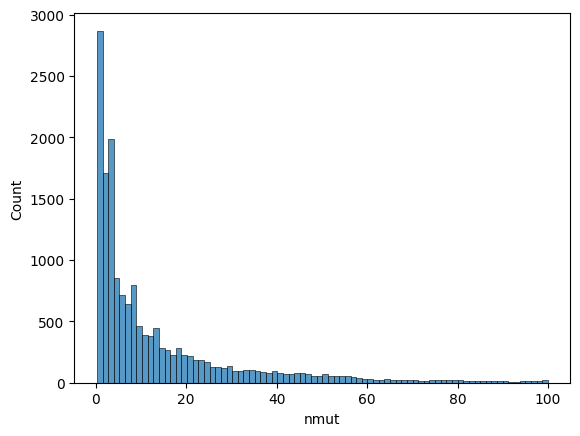

In [116]:
x = mutations_filtered.groupby(['taxid', 'AltNode']).ProbaMut.sum().rename('nmut').reset_index()
sns.histplot(data=x[x.nmut<100], x='nmut')

<Axes: xlabel='taxid', ylabel='nmut'>

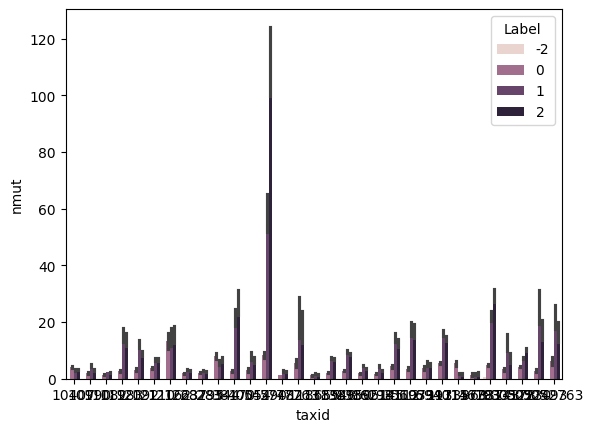

In [117]:
x = mutations_filtered.groupby(['taxid', 'AltNode', 'Label']).ProbaMut.sum().rename('nmut').reset_index()
sns.barplot(data=x, x='taxid', hue='Label', y='nmut')

In [29]:
nmut = mutations_filtered.groupby(['taxid', 'virusname', 'Label']).ProbaMut.sum().unstack().reset_index()
nmut['nsyn'] = nmut[1]+nmut[2]
nmut['n[syn+nonsyn]'] = nmut[0]+nmut[1]+nmut[2]
nmut.head()

Label,taxid,virusname,-2,0,1,2,nsyn,n[syn+nonsyn]
0,10407,HBV,NaN,2383.892893,1479.667486,1715.736464,3195.403950,5579.296843
1,10990,RBSDV,NaN,238.358078,751.610794,443.048654,1194.659448,1433.017526
2,11082,WNV,NaN,468.694983,1158.307262,970.429924,2128.737186,2597.432169
3,11983,norw,NaN,337.475278,2428.890431,2201.663193,4630.553624,4968.028902
4,12092,HAV,NaN,755.872610,4609.999980,3074.808593,7684.808573,8440.681183


In [30]:
final_df = final_df.merge(nmut[['taxid', 'virusname', 'nsyn', 'n[syn+nonsyn]']], how='left', on='taxid')

final_df.to_csv('data/viral_taxid_info_be.csv', index=False)